## Project 2

### part 1

Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Load the CSV dataset using Pandas

In [2]:
df = pd.read_csv("student_performance_2000.csv")

Display 5 rows

In [3]:
df.head()

,Student_ID,Student_Name,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Assignment_Score,Internal_Marks,Exam_Marks,Previous_Semester_Score,Extracurricular_Activities,Internet_Access,Parent_Education,Overall_Score,Performance_Level,Result
0,STU1001,Student_1,Male,21,English,3rd Year,77.4,4.4,85.3,64.2,43.6,45.4,No,Yes,School,64.4,Good,Pass
1,STU1002,Student_2,Female,18,Information Technology,2nd Year,91.7,4.6,81.3,68.8,72.8,89.5,Yes,Yes,Undergraduate,74.3,Good,Pass
2,STU1003,Student_3,Male,20,English,2nd Year,93.3,1.7,78.0,55.4,78.3,99.8,No,Yes,Postgraduate,70.6,Good,Pass
3,STU1004,Student_4,Male,17,Commerce,3rd Year,70.0,4.6,74.9,71.9,62.3,44.7,Yes,Yes,Higher Secondary,69.7,Good,Pass
4,STU1005,Student_5,Male,21,Mathematics,3rd Year,72.2,3.7,46.7,67.4,66.4,100.0,No,Yes,Undergraduate,60.2,Average,Pass


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  2000 non-null   str    
 1   Student_Name                2000 non-null   str    
 2   Gender                      2000 non-null   str    
 3   Age                         2000 non-null   int64  
 4   Department                  2000 non-null   str    
 5   Year                        2000 non-null   str    
 6   Attendance_Percentage       2000 non-null   float64
 7   Study_Hours_Per_Day         2000 non-null   float64
 8   Assignment_Score            2000 non-null   float64
 9   Internal_Marks              2000 non-null   float64
 10  Exam_Marks                  2000 non-null   float64
 11  Previous_Semester_Score     2000 non-null   float64
 12  Extracurricular_Activities  2000 non-null   str    
 13  Internet_Access             2000 non-null   

## part 2

check missing value

In [5]:
#check missing value 
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


Student_ID                    0
Student_Name                  0
Gender                        0
Age                           0
Department                    0
Year                          0
Attendance_Percentage         0
Study_Hours_Per_Day           0
Assignment_Score              0
Internal_Marks                0
Exam_Marks                    0
Previous_Semester_Score       0
Extracurricular_Activities    0
Internet_Access               0
Parent_Education              0
Overall_Score                 0
Performance_Level             0
Result                        0
dtype: int64

Removing duplicate values

In [6]:
#check number of duplicate records
print("Duplicate records:", df.duplicated().sum())

#remove duplicate records
df = df.drop_duplicates()

#checjk again
print("Duplicate records after removal:", df.duplicated().sum)

Duplicate records: 0
Duplicate records after removal: <bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool>


Correct spelling mistake if any

In [7]:
# Correct spelling mistakes

df['Gender'] = df['Gender'].replace({
    'Mlae': 'Male',
    'Fmale': 'Female'
})

df['Department'] = df['Department'].replace({
    'CSEe': 'CSE',
    'ITt': 'IT',
    'ECEe': 'ECE'
})

df['Performance_Level'] = df['Performance_Level'].replace({
    'Averge': 'Average',
    'Godd': 'Good',
    'Excellnt': 'Excellent',
    'Pooor': 'Poor'
})

df['Result'] = df['Result'].replace({
    'Pss': 'Pass',
    'Fal': 'Fail'
})

print("Spelling mistakes corrected successfully!")

Spelling mistakes corrected successfully!


Convert Date column into datetime format

In [8]:
# Convert Year column to numeric format
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Check the data type
print(df['Year'].dtype)

float64


## Part 3

create a  new column

In [9]:
# Create a new column based on Overall Score

df['Performance_Category'] = pd.cut(
    df['Overall_Score'],
    bins=[0, 40, 60, 75, 90, 100],
    labels=['Poor', 'Average', 'Good', 'Very Good', 'Excellent']
)

print(df[['Overall_Score', 'Performance_Category']].head())

   Overall_Score Performance_Category
0           64.4                 Good
1           74.3                 Good
2           70.6                 Good
3           69.7                 Good
4           60.2                 Good


Total Marks

In [10]:
# Create Total_Marks column
df['Total_Marks'] = (
    df['Assignment_Score'] +
    df['Internal_Marks'] +
    df['Exam_Marks']
)

# Display first 5 rows
display(df.head())

,Student_ID,Student_Name,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Assignment_Score,Internal_Marks,Exam_Marks,Previous_Semester_Score,Extracurricular_Activities,Internet_Access,Parent_Education,Overall_Score,Performance_Level,Result,Performance_Category,Total_Marks
0,STU1001,Student_1,Male,21,English,NaN,77.4,4.4,85.3,64.2,43.6,45.4,No,Yes,School,64.4,Good,Pass,Good,193.1
1,STU1002,Student_2,Female,18,Information Technology,NaN,91.7,4.6,81.3,68.8,72.8,89.5,Yes,Yes,Undergraduate,74.3,Good,Pass,Good,222.9
2,STU1003,Student_3,Male,20,English,NaN,93.3,1.7,78.0,55.4,78.3,99.8,No,Yes,Postgraduate,70.6,Good,Pass,Good,211.7
3,STU1004,Student_4,Male,17,Commerce,NaN,70.0,4.6,74.9,71.9,62.3,44.7,Yes,Yes,Higher Secondary,69.7,Good,Pass,Good,209.1
4,STU1005,Student_5,Male,21,Mathematics,NaN,72.2,3.7,46.7,67.4,66.4,100.0,No,Yes,Undergraduate,60.2,Average,Pass,Good,180.5


Step 2 — Create Average Marks

In [11]:
# Create Average_Marks column
df['Average_Marks'] = df['Total_Marks'] / 3

# Display first 5 rows
display(df.head())

,Student_ID,Student_Name,Gender,Age,Department,Year,Attendance_Percentage,Study_Hours_Per_Day,Assignment_Score,Internal_Marks,...,Previous_Semester_Score,Extracurricular_Activities,Internet_Access,Parent_Education,Overall_Score,Performance_Level,Result,Performance_Category,Total_Marks,Average_Marks
0,STU1001,Student_1,Male,21,English,NaN,77.4,4.4,85.3,64.2,...,45.4,No,Yes,School,64.4,Good,Pass,Good,193.1,64.366667
1,STU1002,Student_2,Female,18,Information Technology,NaN,91.7,4.6,81.3,68.8,...,89.5,Yes,Yes,Undergraduate,74.3,Good,Pass,Good,222.9,74.300000
2,STU1003,Student_3,Male,20,English,NaN,93.3,1.7,78.0,55.4,...,99.8,No,Yes,Postgraduate,70.6,Good,Pass,Good,211.7,70.566667
3,STU1004,Student_4,Male,17,Commerce,NaN,70.0,4.6,74.9,71.9,...,44.7,Yes,Yes,Higher Secondary,69.7,Good,Pass,Good,209.1,69.700000
4,STU1005,Student_5,Male,21,Mathematics,NaN,72.2,3.7,46.7,67.4,...,100.0,No,Yes,Undergraduate,60.2,Average,Pass,Good,180.5,60.166667


##  Part 4-Data Analysis 

Task 1 — Overall Student Performance

In [12]:
# Find average overall score
average_score = df['Overall_Score'].mean()

print("Average Overall Score:", average_score)

Average Overall Score: 72.00815


Task 2 — Top Performing Student

In [13]:
# Find student with highest overall score
top_student = df.loc[df['Overall_Score'].idxmax()]

print("Top Performing Student:")
display(top_student)

Top Performing Student:


Student_ID                             STU2267
Student_Name                      Student_1267
Gender                                    Male
Age                                         16
Department                    Computer Science
Year                                       NaN
Attendance_Percentage                     96.1
Study_Hours_Per_Day                        3.5
Assignment_Score                         100.0
Internal_Marks                            91.1
Exam_Marks                                99.1
Previous_Semester_Score                   58.8
Extracurricular_Activities                  No
Internet_Access                            Yes
Parent_Education              Higher Secondary
Overall_Score                             96.7
Performance_Level                    Excellent
Result                                    Pass
Performance_Category                 Excellent
Total_Marks                              290.2
Average_Marks                        96.733333
Name: 1266, d

Task 3 — Best Performing Class

In [14]:
# Find average score for each gender
gender_performance = df.groupby('Gender')['Overall_Score'].mean()

# Find gender with highest average score
best_gender = gender_performance.idxmax()
best_gender_score = gender_performance.max()

print("Best Performing Gender:", best_gender)
print("Average Score:", best_gender_score)

Best Performing Gender: Male
Average Score: 72.02942913385826


Task 4 — Gender Analysis

In [15]:
# Find average score for each gender
gender_analysis = df.groupby('Gender')['Overall_Score'].mean()

print("Average Overall Score by Gender:")
display(gender_analysis)

Average Overall Score by Gender:


Gender
Female    71.986179
Male      72.029429
Name: Overall_Score, dtype: float64

Task 5 — Performance Analysis

In [16]:
# Find average overall score for each performance level
performance_analysis = df.groupby('Performance_Level')['Overall_Score'].mean()

print("Average Score by Performance Level:")
display(performance_analysis)

Average Score by Performance Level:


Performance_Level
Average      59.597546
Excellent    83.523659
Good         71.711422
Low          46.675000
Name: Overall_Score, dtype: float64

## Part 5-Data Visualization

Task 1 — Bar Chart: Average Score by Gender

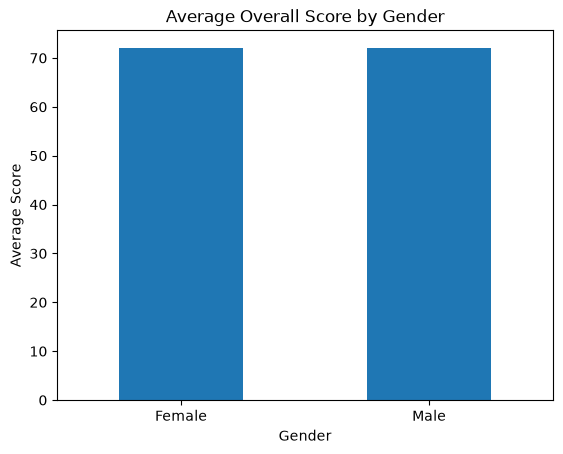

In [17]:
import matplotlib.pyplot as plt

# Calculate average score by gender
gender_scores = df.groupby('Gender')['Overall_Score'].mean()

# Create Bar Chart
gender_scores.plot(kind='bar')

plt.title('Average Overall Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()

Task 2 — Pie Chart: Performance Level Contribution

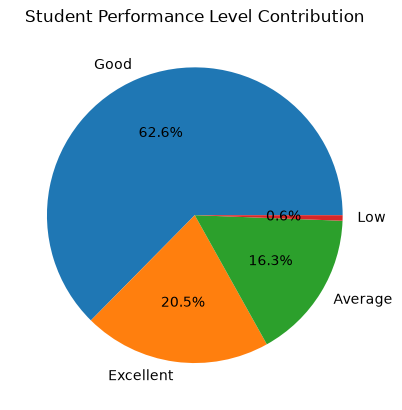

In [18]:
# Count students in each performance level
performance_counts = df['Performance_Level'].value_counts()

# Create Pie Chart
performance_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Student Performance Level Contribution')
plt.ylabel('')
plt.show()

Task 3 — Line Chart: Student Score Trend

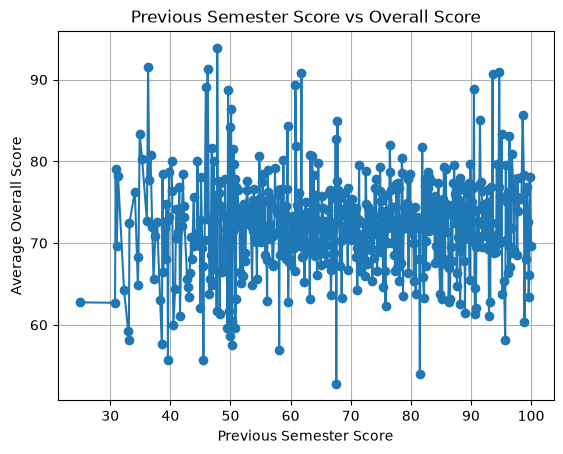

In [19]:
# Calculate average score based on Previous Semester Score
score_trend = df.groupby('Previous_Semester_Score')['Overall_Score'].mean()

# Create Line Chart
score_trend.plot(kind='line', marker='o')

plt.title('Previous Semester Score vs Overall Score')
plt.xlabel('Previous Semester Score')
plt.ylabel('Average Overall Score')
plt.grid(True)
plt.show()

## Part 6-Student Performance Insights

In [20]:
print("1. Students with higher previous semester scores tend to have higher overall scores.")
print("2. Assignment and internal marks contribute to overall student performance.")
print("3. Some students achieve significantly higher overall scores than the average.")
print("4. Performance levels show the distribution of high and low performing students.")
print("5. Average overall scores vary among different student groups.")

1. Students with higher previous semester scores tend to have higher overall scores.
2. Assignment and internal marks contribute to overall student performance.
3. Some students achieve significantly higher overall scores than the average.
4. Performance levels show the distribution of high and low performing students.
5. Average overall scores vary among different student groups.


## Part 7-Recommendations

In [21]:
print("1. Provide additional coaching and study support for students with low scores.")
print("2. Conduct regular assessments to identify students who need improvement.")
print("3. Encourage students to improve their assignment and internal assessment performance.")

1. Provide additional coaching and study support for students with low scores.
2. Conduct regular assessments to identify students who need improvement.
3. Encourage students to improve their assignment and internal assessment performance.
